In [11]:
import sys
sys.path.append('../../datasets')
#from spark_utils import *
import getpass
import pathlib
import os
import io
from tqdm import tqdm
from optuna.samplers import TPESampler
#import datadicts as dd
import pathlib
import sys
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import sklearn
import catboost as cb
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn import metrics
import optuna
import shap
#from optuna.samplers import TPESampler
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, confusion_matrix, precision_recall_curve, roc_curve
import warnings
warnings.filterwarnings('ignore')

import pickle

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder

In [2]:
final_df = pd.read_parquet('final_new.parquet')

# XGBoost

In [119]:
import xgboost
from xgboost import XGBClassifier

In [5]:
with open ('features_dict.pkl', 'rb') as f:
    feature_names = pickle.load(f)
    
from catboost import Pool

In [91]:
def show_importances_xgb(model=None, num : int = None) -> pd.DataFrame:
    feature_ids = model.get_booster().feature_names
    importances_value = model.feature_importances_
    
    importances = pd.DataFrame({
        'Feature Id': feature_ids,
        'Importances': importances_value
    })
    
    importances['Фичи'] = importances['Feature Id'].map(feature_names)
    importances['Фичи'] = importances['Фичи'].fillna(importances['Feature Id'])
    
    importances = importances.sort_values(
        'Importances',
        ascending=False
    ).reset_index(drop=True)
    
    return importances.head(num) if num else importances.head(min(len(importances), 30))

In [6]:
x = final_df.drop(columns=['target'])
y = final_df['target']

In [7]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size = 0.25, random_state = 0)

## First iter

In [ ]:
srv_mb_econ_qty_sum_6m, srv_mb_full_qty_sum_12m, crd_tot_act_spend_qty, dep_acct_tot_qty_sum_3m, crd_dc_act_spend_qty_sum_12m, crd_dc_open_qty_sum_9m

In [57]:
x_train = x_train.drop(columns=['crd_dc_open_qty_sum_9m'])
x_val = x_val.drop(columns=['crd_dc_open_qty_sum_9m'])
x_test = x_test.drop(columns=['crd_dc_open_qty_sum_9m'])

In [58]:
cat_features = x_train.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
num_features = x_train.select_dtypes(include=['int64', 'int32', 'float64', 'float32']).columns.tolist()

In [59]:
x_train_encoded = x_train.copy()
x_val_encoded = x_val.copy()
x_test_encoded = x_test.copy()

In [60]:
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
x_train_encoded[cat_features] = encoder.fit_transform(x_train_encoded[cat_features])
x_val_encoded[cat_features] = encoder.transform(x_val_encoded[cat_features])
x_test_encoded[cat_features] = encoder.transform(x_test_encoded[cat_features])

In [61]:
model_xgb = XGBClassifier(n_estimators = 1000, learning_rate = 0.1, max_depth = 5, random_state=0, early_stopping_rounds=100)
model_xgb.fit(x_train_encoded, y_train, eval_set=[(x_val_encoded, y_val)], verbose=100)

[0]	validation_0-logloss:0.62114
[100]	validation_0-logloss:0.51967
[147]	validation_0-logloss:0.53050


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=100,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1000, n_jobs=None,
              num_parallel_tree=None, random_state=0, ...)

In [62]:
print(f"TRAIN : {roc_auc_score(y_train, model_xgb.predict_proba(x_train_encoded)[:, 1])}")
print(f"VAL : {roc_auc_score(y_val, model_xgb.predict_proba(x_val_encoded)[:, 1])}")
print(f"TEST : {roc_auc_score(y_test, model_xgb.predict_proba(x_test_encoded)[:, 1])}")

TRAIN : 0.7659830584075529
VAL : 0.6978249293365567
TEST : 0.696942454582941


In [63]:
print(f"TRAIN : {f1_score(y_train, model_xgb.predict(x_train_encoded))}")
print(f"VAL : {f1_score(y_val, model_xgb.predict(x_val_encoded))}")
print(f"TEST : {f1_score(y_test, model_xgb.predict(x_test_encoded))}")

TRAIN : 0.32457544407573685
VAL : 0.2200624783061437
TEST : 0.21945781011618354


In [64]:
score_dict = model_xgb.get_booster().get_score(importance_type='gain')

feature_importance = (
    pd.DataFrame(
        score_dict.items(),
        columns=['feature', 'importance']
    )
    .sort_values('importance', ascending=False)
)

In [65]:
feature_importance.head(30)

,feature,importance
775,crd_tot_act_qty_sum_6m,214.548676
365,crd_otf_total_rub_amt_sum_12m,213.979355
207,crd_tot_act_qty,181.111420
735,crd_cc_mnth_snc_issue_qty_sum_3m,149.097504
751,dep_mnth_payroll_min_qty_sum_3m,146.118317
793,crd_otf_total_qty_sum_12m,122.957352
753,dep_mnth_social_min_qty_sum_3m,99.905800
25,crd_dc_mnth_snc_lst_open_qty,82.098824
285,crd_otf_total_rub_amt_12m,77.165161
761,crd_cc_issued_qty_sum_6m,74.814919


In [82]:
best_features = (
    feature_importance.loc[feature_importance['importance'] > 7, 'feature'].tolist()
)

In [83]:
len(best_features)

131

## Second iter

In [84]:
x_train_encoded_new = x_train_encoded[best_features]
x_val_encoded_new = x_val_encoded[best_features]
x_test_encoded_new = x_test_encoded[best_features]

In [86]:
model_xgb = XGBClassifier(n_estimators = 1000, learning_rate = 0.1, max_depth = 5, random_state=0, early_stopping_rounds=100)
model_xgb.fit(x_train_encoded_new, y_train, eval_set=[(x_val_encoded_new, y_val)], verbose=100)

[0]	validation_0-logloss:0.62115
[100]	validation_0-logloss:0.51209
[154]	validation_0-logloss:0.52084


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=100,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1000, n_jobs=None,
              num_parallel_tree=None, random_state=0, ...)

In [87]:
print(f"TRAIN : {roc_auc_score(y_train, model_xgb.predict_proba(x_train_encoded_new)[:, 1])}")
print(f"VAL : {roc_auc_score(y_val, model_xgb.predict_proba(x_val_encoded_new)[:, 1])}")
print(f"TEST : {roc_auc_score(y_test, model_xgb.predict_proba(x_test_encoded_new)[:, 1])}")

TRAIN : 0.7635774708722829
VAL : 0.702945319656938
TEST : 0.700146088134915


In [88]:
print(f"TRAIN : {f1_score(y_train, model_xgb.predict(x_train_encoded_new))}")
print(f"VAL : {f1_score(y_val, model_xgb.predict(x_val_encoded_new))}")
print(f"TEST : {f1_score(y_test, model_xgb.predict(x_test_encoded_new))}")

TRAIN : 0.34291310407171643
VAL : 0.25495495495495496
TEST : 0.2457732894587541


In [89]:
print(classification_report(y_test, model_xgb.predict(x_test_encoded_new)))

              precision    recall  f1-score   support

         0.0       0.68      0.87      0.76     12285
         1.0       0.40      0.18      0.25      6086

    accuracy                           0.64     18371
   macro avg       0.54      0.52      0.50     18371
weighted avg       0.59      0.64      0.59     18371



## Third iter

In [97]:
def simple_train_xgb(target_column = 'target', features = None, model_params = None):
    features = x_train_encoded_new.columns.tolist() if features is None else features
    text_columns = x_train_encoded_new[features].select_dtypes('object').columns.tolist()
    
    x_train_part = x_train_encoded_new[features]
    x_val_part = x_val_encoded_new[features]
    x_test_part = x_test_encoded_new[features]

    model_xgb = XGBClassifier(n_estimators = 1000, learning_rate = 0.1, max_depth = 5, random_state=0, early_stopping_rounds=100)
    
        
    model_xgb.fit(x_train_part, y_train, eval_set=[(x_val_part, y_val)], verbose=100)

    
    
    train_preds = model_xgb.predict(x_train_part)
    train_probas = model_xgb.predict_proba(x_train_part)[:, 1]
    
    val_preds = model_xgb.predict(x_val_part)
    val_probas = model_xgb.predict_proba(x_val_part)[:, 1]
    
    
    test_preds = model_xgb.predict(x_test_part)
    test_probas = model_xgb.predict_proba(x_test_part)[:, 1]
    
    
    
    return train_preds, train_probas, val_preds, val_probas, test_preds, test_probas, model_xgb

In [98]:
target_column = 'target' 
RANDOM_STATE = 0

train_roc_auc = []
val_roc_auc = []
test_roc_auc = []


train_f1 = []
val_f1 = []
test_f1 = []


importances  = show_importances_xgb(model_xgb, -1)['Feature Id'].tolist()

xticks = range(1, len(best_features), 5)

for num_features in tqdm(xticks):
    used_features = importances[: num_features]
    
    
    train_preds, train_probas, val_preds, val_probas, test_preds, test_probas, model_temp = simple_train_xgb(target_column, used_features)

    train_f1.append(f1_score(y_train, train_preds))
    val_f1.append(f1_score(y_val, val_preds))
    test_f1.append(f1_score(y_test, test_preds))


    train_roc_auc.append(roc_auc_score(y_train, train_probas))
    val_roc_auc.append(roc_auc_score(y_val, val_probas))
    test_roc_auc.append(roc_auc_score(y_test, test_probas))

  0%|          | 0/26 [00:00<?, ?it/s]

[0]	validation_0-logloss:0.62721
[100]	validation_0-logloss:0.56466
[200]	validation_0-logloss:0.56432
[280]	validation_0-logloss:0.56434


  4%|▍         | 1/26 [00:01<00:28,  1.14s/it]

[0]	validation_0-logloss:0.62153
[100]	validation_0-logloss:0.51684
[198]	validation_0-logloss:0.52050


  8%|▊         | 2/26 [00:02<00:26,  1.10s/it]

...

 92%|█████████▏| 24/26 [00:44<00:05,  2.72s/it]

[0]	validation_0-logloss:0.62115
[100]	validation_0-logloss:0.51179
[149]	validation_0-logloss:0.51912


 96%|█████████▌| 25/26 [00:47<00:02,  2.78s/it]

[0]	validation_0-logloss:0.62115
[100]	validation_0-logloss:0.51179
[154]	validation_0-logloss:0.52108


100%|██████████| 26/26 [00:50<00:00,  1.94s/it]


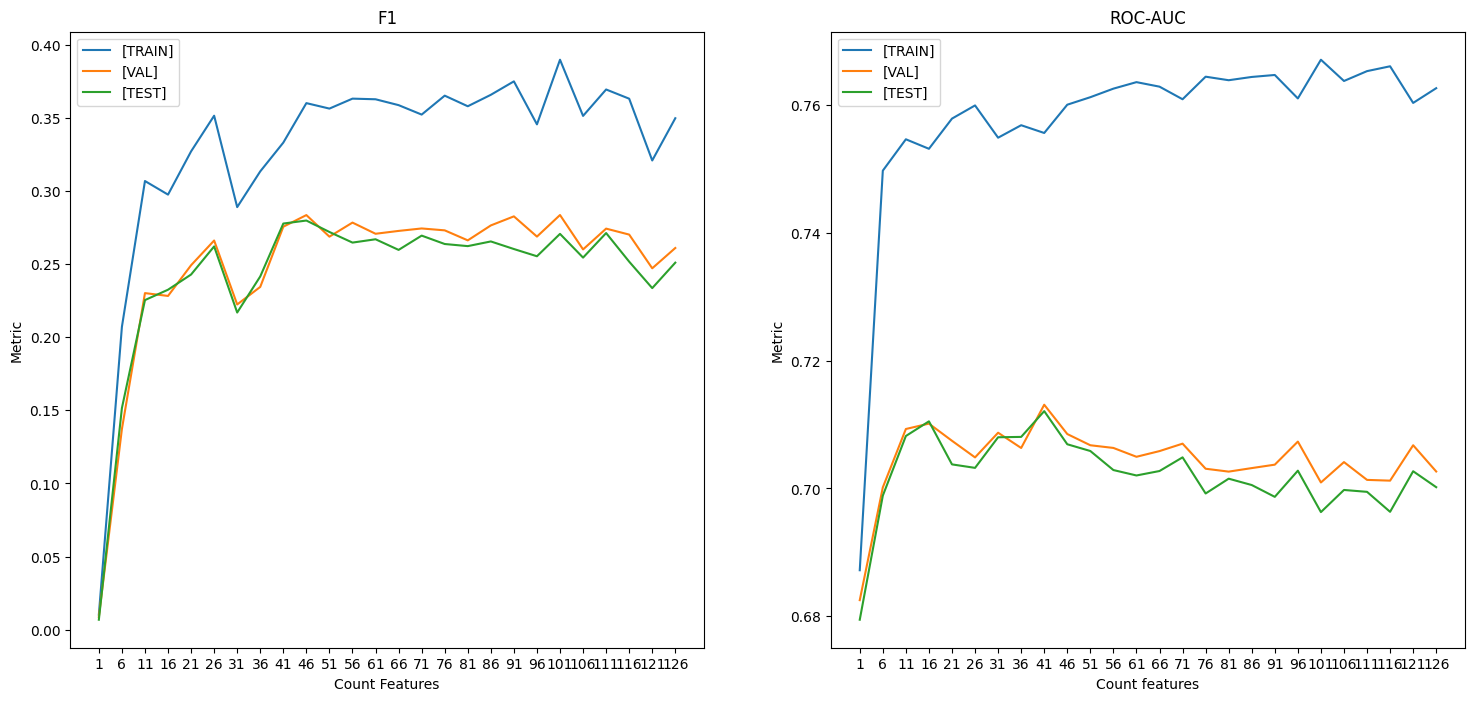

In [99]:
fig, axs = plt.subplots(ncols = 2, figsize = (18, 8), )


plt.ylabel('Metric')
plt.xlabel('Count features')


axs[0].plot(train_f1, label = '[TRAIN]')
axs[0].plot(val_f1, label = '[VAL]')
axs[0].plot(test_f1, label = '[TEST]')

axs[0].set_title('F1')
axs[0].set_xticks(ticks = list(range(len(train_f1))), labels = xticks)
axs[0].set_xlabel('Count Features')
axs[0].set_ylabel('Metric')




axs[1].plot(train_roc_auc, label = '[TRAIN]')
axs[1].plot(val_roc_auc, label = '[VAL]')
axs[1].plot(test_roc_auc, label = '[TEST]')

axs[1].set_title('ROC-AUC')
axs[1].set_xlabel('Count features')
axs[1].set_ylabel('Metric')

axs[1].set_xticks(ticks = list(range(len(train_f1))), labels = xticks)

axs[0].legend()

axs[1].legend();

In [109]:
num_features = 41
final_features = importances[:num_features]

In [110]:
final_features

['crd_tot_act_qty_sum_6m',
 'dep_mnth_payroll_min_qty_sum_3m',
 'crd_tot_act_qty',
 'crd_otf_total_rub_amt_sum_12m',
 'crd_cc_mnth_snc_issue_qty_sum_3m',
 'dep_mnth_social_min_qty_sum_3m',
 'seg_service_channel_cd',
 'crd_dc_mnth_snc_lst_open_qty',
 'crd_dc_act_qty_sum_3_6',
 'crd_cc_issued_qty_sum_6m',
 'crd_otf_total_qty_sum_12m',
 'crd_cc_open_qty_sum_6m',
 'srv_thanks_mnth_qty_sum_12m',
 'dep_inf_new_acct_qty_sum_6m',
 'crd_otf_total_qty_12m',
 'crd_cc_clsd_qty',
 'crd_otf_total_rub_amt_12m',
 'crd_tot_act_qty_sum_3_6',
 'srv_sbol_1st_login_ever_dt',
 'seg_client_sb_segment_cd',
 'srv_dc_m2m_otf_on_amt_sum_6_9',
 'crd_cc_utilization_pct_sum_9m',
 'dep_mnth_payroll_min_qty_sum_6_9',
 'crd_cc_lst_open_dt',
 'tp_active_kind_cd',
 'crd_dc_mnth_snc_open_qty_sum_3m',
 'crd_cc_open_qty_sum_3_6',
 'crd_dc_pos_utilities_rub_amt_sum_9_12',
 'dep_inf_total_qty_sum_12m',
 'srv_thanks_mnth_qty_sum_9_12',
 'crd_otf_dc_total_qty_sum_9_12',
 'prd_prot_bliz_active_nflag',
 'bo_agrmnt_bal_tot_nflag'

## Last

In [111]:
x_train_encoded_new = x_train_encoded[final_features]
x_val_encoded_new = x_val_encoded[final_features]
x_test_encoded_new = x_test_encoded[final_features]

In [112]:
model_xgb = XGBClassifier(n_estimators = 1000, learning_rate = 0.1, max_depth = 5, random_state=0, early_stopping_rounds=100)
model_xgb.fit(x_train_encoded_new, y_train, eval_set=[(x_val_encoded_new, y_val)], verbose=100)

[0]	validation_0-logloss:0.62113
[100]	validation_0-logloss:0.50568
[157]	validation_0-logloss:0.51039


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=100,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1000, n_jobs=None,
              num_parallel_tree=None, random_state=0, ...)

In [113]:
# 41
print(f"TRAIN : {roc_auc_score(y_train, model_xgb.predict_proba(x_train_encoded_new)[:, 1])}")
print(f"VAL : {roc_auc_score(y_val, model_xgb.predict_proba(x_val_encoded_new)[:, 1])}")
print(f"TEST : {roc_auc_score(y_test, model_xgb.predict_proba(x_test_encoded_new)[:, 1])}")

TRAIN : 0.755670009192748
VAL : 0.7131052940890111
TEST : 0.7121022166207839


In [114]:
# 41
print(f"TRAIN : {f1_score(y_train, model_xgb.predict(x_train_encoded_new))}")
print(f"VAL : {f1_score(y_val, model_xgb.predict(x_val_encoded_new))}")
print(f"TEST : {f1_score(y_test, model_xgb.predict(x_test_encoded_new))}")

TRAIN : 0.3329592218481108
VAL : 0.2754691689008043
TEST : 0.2776338028169014


In [115]:
print(classification_report(y_test, model_xgb.predict(x_test_encoded_new)))

              precision    recall  f1-score   support

         0.0       0.69      0.87      0.77     12285
         1.0       0.44      0.20      0.28      6086

    accuracy                           0.65     18371
   macro avg       0.57      0.54      0.52     18371
weighted avg       0.61      0.65      0.61     18371



In [120]:
x_shap = x_test_encoded_new.sample(n=min(5000, len(x_test_encoded_new)), random_state=0)

d_matrix = xgboost.DMatrix(x_shap, feature_names=x_shap.columns.tolist())

shap_contribs = model_xgb.get_booster().predict(d_matrix, pred_contribs=True)

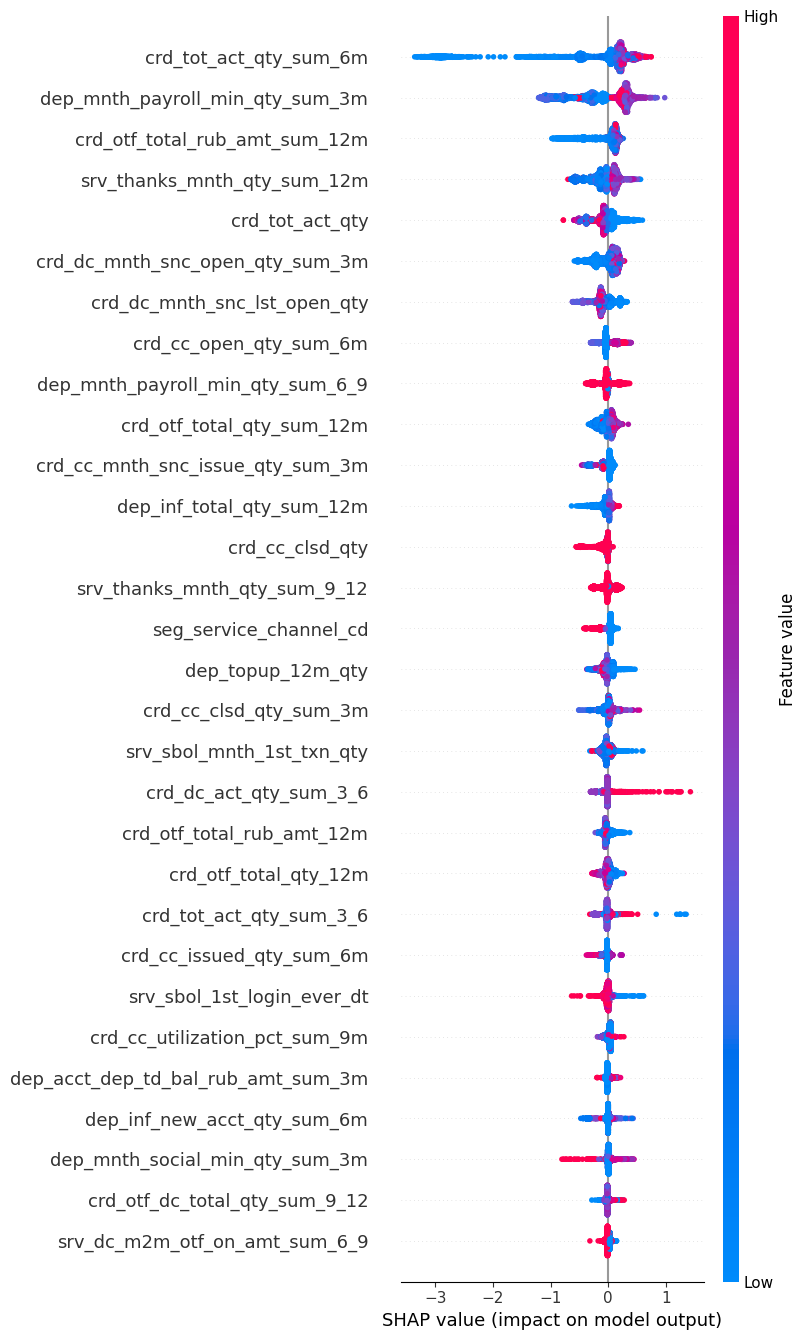

In [123]:
shap_values = shap_contribs[:, :-1]
base_values = shap_contribs[:, -1]

shap.summary_plot(shap_values, x_shap, max_display=30)